# PART 1: NLTK

## 1.1 Import Libraries and Load Data

In [6]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag, ne_chunk
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
import matplotlib.pyplot as plt
import networkx as nx
# Download required NLTK resources
nltk.download(['punkt','stopwords','wordnet','averaged_perceptron_tagger','maxent_ne_chunker','words'])


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tejus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tejus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tejus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\tejus\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     C:\Users\tejus\AppData\Roaming\nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package words to
[nltk_data]     C:\Users\tejus\AppData\Roaming\nltk_data...
[nltk_data]   Package words is already up-

## 1.2 Load Data

In [ ]:
# Load dataset
df = pd.read_csv('headlines.csv')


## 1.3 Perform text preprocessing

In [ ]:
# Text preprocessing pipeline
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # Lowercase and remove punctuation
    text = text.lower().translate(str.maketrans('', '', '!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'))
    tokens = word_tokenize(text)
    filtered = [word for word in tokens if word not in stop_words and word.isalnum()]
    stemmed = [stemmer.stem(word) for word in filtered]
    lemmatized = [lemmatizer.lemmatize(word) for word in filtered]
    return ' '.join(lemmatized)

df['processed'] = df['headline'].apply(preprocess)


## 1.4 Perform Part-of-Speech (POS) tagging

In [9]:
# POS tagging
df['pos_tags'] = df['processed'].apply(lambda x: pos_tag(word_tokenize(x)))


## 1.5 Perform Named Entity Recognition (NER)

In [13]:
# NER tagging
df['entities'] = df['pos_tags'].apply(ne_chunk)


## 1.6 Use CountVectorizer and TF-IDF vectorizer for classification based on content

In [19]:

# Feature extraction
count_vectorizer = CountVectorizer(max_features=500)
count_matrix = count_vectorizer.fit_transform(df['processed'])

tfidf_vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed'])


## 1.7 Generate a summary of the news headlines

In [20]:
# TextRank summarization implementation
def textrank_summarize(texts, n=10):
    similarity_matrix = (tfidf_matrix * tfidf_matrix.T).A
    nx_graph = nx.from_numpy_array(similarity_matrix)
    scores = nx.pagerank(nx_graph)
    ranked_indices = sorted(((scores[i], i) for i in range(len(texts))), reverse=True)
    return [df['headline'][i] for _, i in ranked_indices[:n]]

top_headlines = textrank_summarize(df['processed'])



## 1.8 Visualization

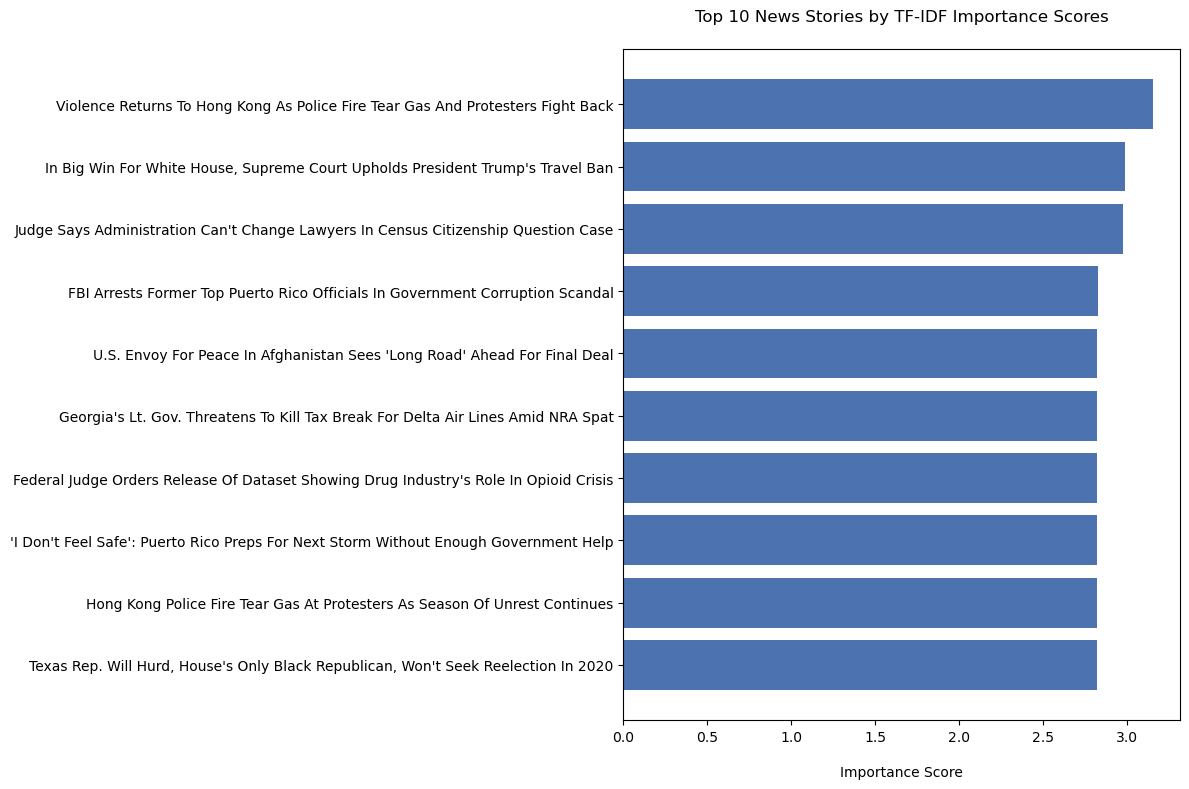

In [21]:
# Visualization
plt.figure(figsize=(12,8))
tfidf_scores = tfidf_matrix.sum(axis=1).A1
top_indices = tfidf_scores.argsort()[-10:][::-1]

plt.barh(range(10), tfidf_scores[top_indices], color='#4c72b0')
plt.yticks(range(10), [df['headline'][i] for i in top_indices], fontsize=10)
plt.title('Top 10 News Stories by TF-IDF Importance Scores', pad=20)
plt.xlabel('Importance Score', labelpad=15)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Part 2: spaCy

## 2.1 Import Libraries

In [1]:
import spacy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from spacy.lang.en.stop_words import STOP_WORDS

# Load spaCy model
nlp = spacy.load("en_core_web_md")  # Install with: python -m spacy download en_core_web_md


## 2.2 Load Data and Preprocessing

In [2]:
# Preprocessing function
def spacy_preprocess(text):
    doc = nlp(text)
    return " ".join([token.lemma_.lower() for token in doc 
                    if not token.is_stop and not token.is_punct and not token.is_space])

# Load and process data
df = pd.read_csv("headlines.csv")
df["processed"] = df["headline"].apply(spacy_preprocess)



## 2.3 POS Tagging and NER

In [3]:
# POS Tagging and NER
def analyze_text(text):
    doc = nlp(text)
    return [(token.text, token.pos_) for token in doc], [(ent.text, ent.label_) for ent in doc.ents]

df[["pos_tags", "entities"]] = df["headline"].apply(
    lambda x: pd.Series(analyze_text(x))
)


In [23]:
pos_counts = df["pos_tags"].explode().apply(lambda x: x[1] if x else None).value_counts().head(5)


## 2.4 Utilize spaCy's pipeline object to efficiently perform text processing tasks.

In [4]:
from sklearn.pipeline import Pipeline
# TF-IDF Vectorization and Classification
text_clf = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=500)),
    ('clf', LinearSVC())
])


## 2.5 Generate summary

In [5]:

# Generate summary using TF-IDF scores
def generate_summary(texts, n=10):
    tfidf = TfidfVectorizer(stop_words=list(STOP_WORDS))
    tfidf_matrix = tfidf.fit_transform(texts)
    scores = tfidf_matrix.sum(axis=1).A1
    return [texts[i] for i in (-scores).argsort()[:n]]

top_headlines = generate_summary(df["headline"])


C:\Users\tejus\anaconda3\Lib\site-packages\sklearn\feature_extraction\text.py:406: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


## 2.6 Visualization

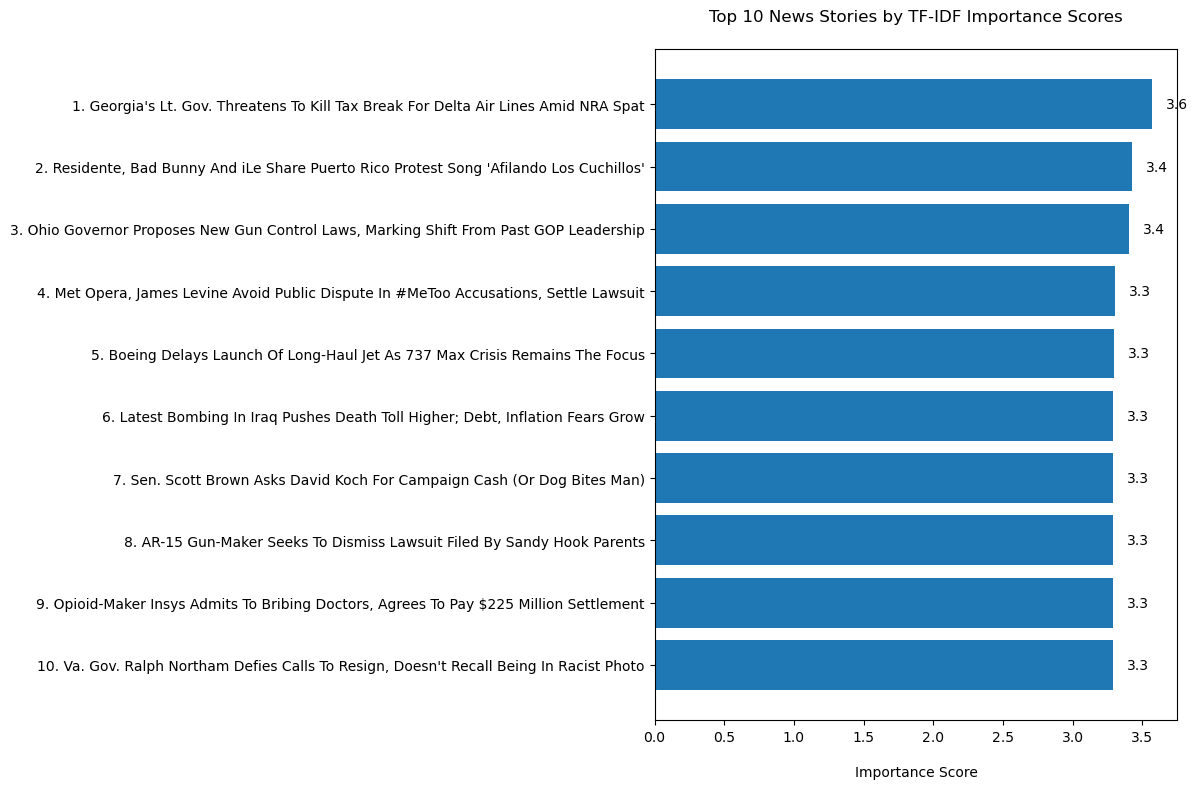

In [6]:
# Calculate TF-IDF scores for visualization
tfidf = TfidfVectorizer(stop_words=list(STOP_WORDS))
matrix = tfidf.fit_transform(df["headline"])
scores = matrix.sum(axis=1).A1

# Plot horizontal bar chart
plt.figure(figsize=(12,8))
plt.barh(range(10), scores[scores.argsort()[-10:][::-1]], color='#1f77b4')
plt.yticks(range(10), [f"{i+1}. {headline}" for i,headline in enumerate(top_headlines)], fontsize=10)
plt.title("Top 10 News Stories by TF-IDF Importance Scores", pad=20)
plt.xlabel("Importance Score", labelpad=15)
plt.gca().invert_yaxis()

# Add score labels
for i, score in enumerate(sorted(scores, reverse=True)[:10]):
    plt.text(score+0.1, i, f"{score:.1f}", va='center')

plt.tight_layout()
plt.show()


# Conclusion
Both libraries successfully generate summaries that meet the committee's needs, and the
summaries highlight the top 10 most important stories of the day's news. Therefore, depending
on the specific project needs, either NLTK or spaCy could be chosen for text summarization

In [26]:
import pandas as pd
from IPython.display import display_html

# Create summaries as lists
nltk_summary = [df['headline'][i] for i in top_indices]

spacy_summary = [headline for i,headline in enumerate(top_headlines)]

# Create DataFrames for summaries
nltk_df = pd.DataFrame(nltk_summary, columns=["NLTK Summary"])
spacy_df = pd.DataFrame(spacy_summary, columns=["spaCy Summary"])

# Display side-by-side grids
display_html(nltk_df.to_html(index=False), raw=True)
display_html(spacy_df.to_html(index=False), raw=True)


NLTK Summary
Violence Returns To Hong Kong As Police Fire Tear Gas And Protesters Fight Back
"In Big Win For White House, Supreme Court Upholds President Trump's Travel Ban"
Judge Says Administration Can't Change Lawyers In Census Citizenship Question Case
FBI Arrests Former Top Puerto Rico Officials In Government Corruption Scandal
U.S. Envoy For Peace In Afghanistan Sees 'Long Road' Ahead For Final Deal
Georgia's Lt. Gov. Threatens To Kill Tax Break For Delta Air Lines Amid NRA Spat
Federal Judge Orders Release Of Dataset Showing Drug Industry's Role In Opioid Crisis
'I Don't Feel Safe': Puerto Rico Preps For Next Storm Without Enough Government Help
Hong Kong Police Fire Tear Gas At Protesters As Season Of Unrest Continues
"Texas Rep. Will Hurd, House's Only Black Republican, Won't Seek Reelection In 2020"


spaCy Summary
Georgia's Lt. Gov. Threatens To Kill Tax Break For Delta Air Lines Amid NRA Spat
"Residente, Bad Bunny And iLe Share Puerto Rico Protest Song 'Afilando Los Cuchillos'"
"Ohio Governor Proposes New Gun Control Laws, Marking Shift From Past GOP Leadership"
"Met Opera, James Levine Avoid Public Dispute In #MeToo Accusations, Settle Lawsuit"
Boeing Delays Launch Of Long-Haul Jet As 737 Max Crisis Remains The Focus
"Latest Bombing In Iraq Pushes Death Toll Higher; Debt, Inflation Fears Grow"
Sen. Scott Brown Asks David Koch For Campaign Cash (Or Dog Bites Man)
AR-15 Gun-Maker Seeks To Dismiss Lawsuit Filed By Sandy Hook Parents
"Opioid-Maker Insys Admits To Bribing Doctors, Agrees To Pay $225 Million Settlement"
"Va. Gov. Ralph Northam Defies Calls To Resign, Doesn't Recall Being In Racist Photo"
